In [45]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from lightgbm import LGBMRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer
import warnings
warnings.filterwarnings('ignore')

RSEED = 42
N_SPLITS = 5

In [46]:
def train_lightgbm_linear_with_stratified_cv(
    X,
    y,
    n_folds=5,
    n_bins=10,
    random_state=42
):
    """
    Train LightGBM (linear_tree=True) using Stratified K-Fold CV for regression.
    Returns out-of-fold (OOF) predictions for actual vs predicted analysis.
    """

    # ------------------------------------------------------------
    # Input handling
    # ------------------------------------------------------------
    if isinstance(X, pd.DataFrame):
        X_values = X.values
        feature_names = X.columns
    else:
        X_values = X
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]

    y = np.asarray(y)

    # ------------------------------------------------------------
    # Bin target for stratification
    # ------------------------------------------------------------
    binner = KBinsDiscretizer(
        n_bins=n_bins,
        encode="ordinal",
        strategy="quantile"
    )
    y_binned = binner.fit_transform(y.reshape(-1, 1)).ravel()

    # ------------------------------------------------------------
    # Stratified K-Fold
    # ------------------------------------------------------------
    skf = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    # ------------------------------------------------------------
    # LightGBM parameters
    # ------------------------------------------------------------
    params = {
        'n_estimators': 10000,
        'boosting_type': 'gbdt',
        'objective': 'regression',
        'metric': 'rmse',
        'linear_tree': True,
        'verbose': -1,
        #'learning_rate': 0.004,

        'lambda_l1': 0.1,
        'lambda_l2': 0.1,
        'max_depth': 6,
        'min_data_in_leaf': 20,
        'min_gain_to_split': 0,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'path_smooth': 0.1
    }

    # ------------------------------------------------------------
    # Storage
    # ------------------------------------------------------------
    models = []
    scalers = []
    rmse_scores = []
    fold_importance = []
    cv_results = []

    oof_predictions = np.zeros(len(y))
    oof_folds = np.zeros(len(y), dtype=int)

    # ------------------------------------------------------------
    # Cross-Validation
    # ------------------------------------------------------------
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_values, y_binned), 1):
        print(f"Training fold {fold}/{n_folds}")

        X_train, X_val = X_values[train_idx], X_values[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # ------------------- Scaling (NO leakage) ----------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # ------------------- LightGBM Dataset --------------------
        train_data = lgb.Dataset(X_train_scaled, label=y_train)
        val_data = lgb.Dataset(X_val_scaled, label=y_val, reference=train_data)

        # ------------------- Train -------------------------------
        model = lgb.train(
            params,
            train_data,
            num_boost_round=100,
            valid_sets=[val_data],
            early_stopping_rounds=10,
            verbose_eval=False
        )

        # ------------------- Predict -----------------------------
        y_pred = model.predict(X_val_scaled)

        # ------------------- Store OOF ---------------------------
        oof_predictions[val_idx] = y_pred
        oof_folds[val_idx] = fold

        rmse = np.sqrt(mse(y_val, y_pred))
        rmse_scores.append(rmse)

        models.append(model)
        scalers.append(scaler)

        fold_importance.append(
            dict(zip(feature_names, model.feature_importance()))
        )

        cv_results.append({
            'fold': fold,
            'rmse': rmse,
            'best_iteration': model.best_iteration
        })

    # ------------------------------------------------------------
    # Aggregate Feature Importance
    # ------------------------------------------------------------
    all_features = set().union(*fold_importance)
    avg_importance = {
        f: np.mean([imp.get(f, 0) for imp in fold_importance])
        for f in all_features
    }
    avg_importance = dict(
        sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)
    )

    # ------------------------------------------------------------
    # CV Summary
    # ------------------------------------------------------------
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)

    print("\nStratified Cross-Validation Results")
    print(f"Mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

    cv_results_df = pd.DataFrame(cv_results)

    # ------------------------------------------------------------
    # OOF DataFrame (Actual vs Predicted)
    # ------------------------------------------------------------
    oof_df = pd.DataFrame({
        "fold": oof_folds,
        "actual": y,
        "predicted": oof_predictions
    })

    return (
        models,
        scalers,
        mean_rmse,
        std_rmse,
        avg_importance,
        cv_results_df,
        oof_df
    )


In [47]:
MyData_train_df = pd.read_csv(r'..\..\data\kaggle_student_test_scores_train.csv') 
MyData_train_df.shape

(630000, 13)

In [48]:
MyData_test_df = pd.read_csv(r'..\..\data\kaggle_student_test_scores_test.csv') 
MyData_test_df.shape

(270000, 12)

In [49]:
sub = pd.read_csv(r'..\..\data\kaggle_diabettes_sample_submission.csv') 
sub.shape

(300000, 2)

In [50]:
# Display all rows but skip the first column
# display(train.iloc[:, 1:].head(10))

In [51]:
# Display the first 10 rows of train, excluding the first column
# display(train.iloc[:10, 1:])

## Explratory Data Analysis
* **Meancharges by categorical columns**

In [52]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality','study_method','facility_rating','exam_difficulty']

for col in categorical_cols:
    grouped_data = MyData_train_df[[col, 'exam_score']].groupby(col).mean()
    print(f"Mean charges by {col}:")
    print(grouped_data)
    print()

Mean charges by gender:
        exam_score
gender            
female   62.563220
male     62.175561
other    62.781191

Mean charges by course:
         exam_score
course             
b.com     62.537726
b.sc      62.295491
b.tech    62.519707
ba        61.886931
bba       63.232038
bca       62.586227
diploma   62.404354

Mean charges by internet_access:
                 exam_score
internet_access            
no                62.478038
yes               62.509172

Mean charges by sleep_quality:
               exam_score
sleep_quality            
average         62.662000
good            67.884885
poor            56.995470

Mean charges by study_method:
               exam_score
study_method             
coaching        69.266665
group study     60.531838
mixed           65.101735
online videos   59.727607
self-study      57.700155

Mean charges by facility_rating:
                 exam_score
facility_rating            
high              66.707126
low               57.954546
medium   

## Visualizing Categorical Distributions
* **countplot(): Displays counts for each category**
* **Helps identify balance or skew in categorical features**

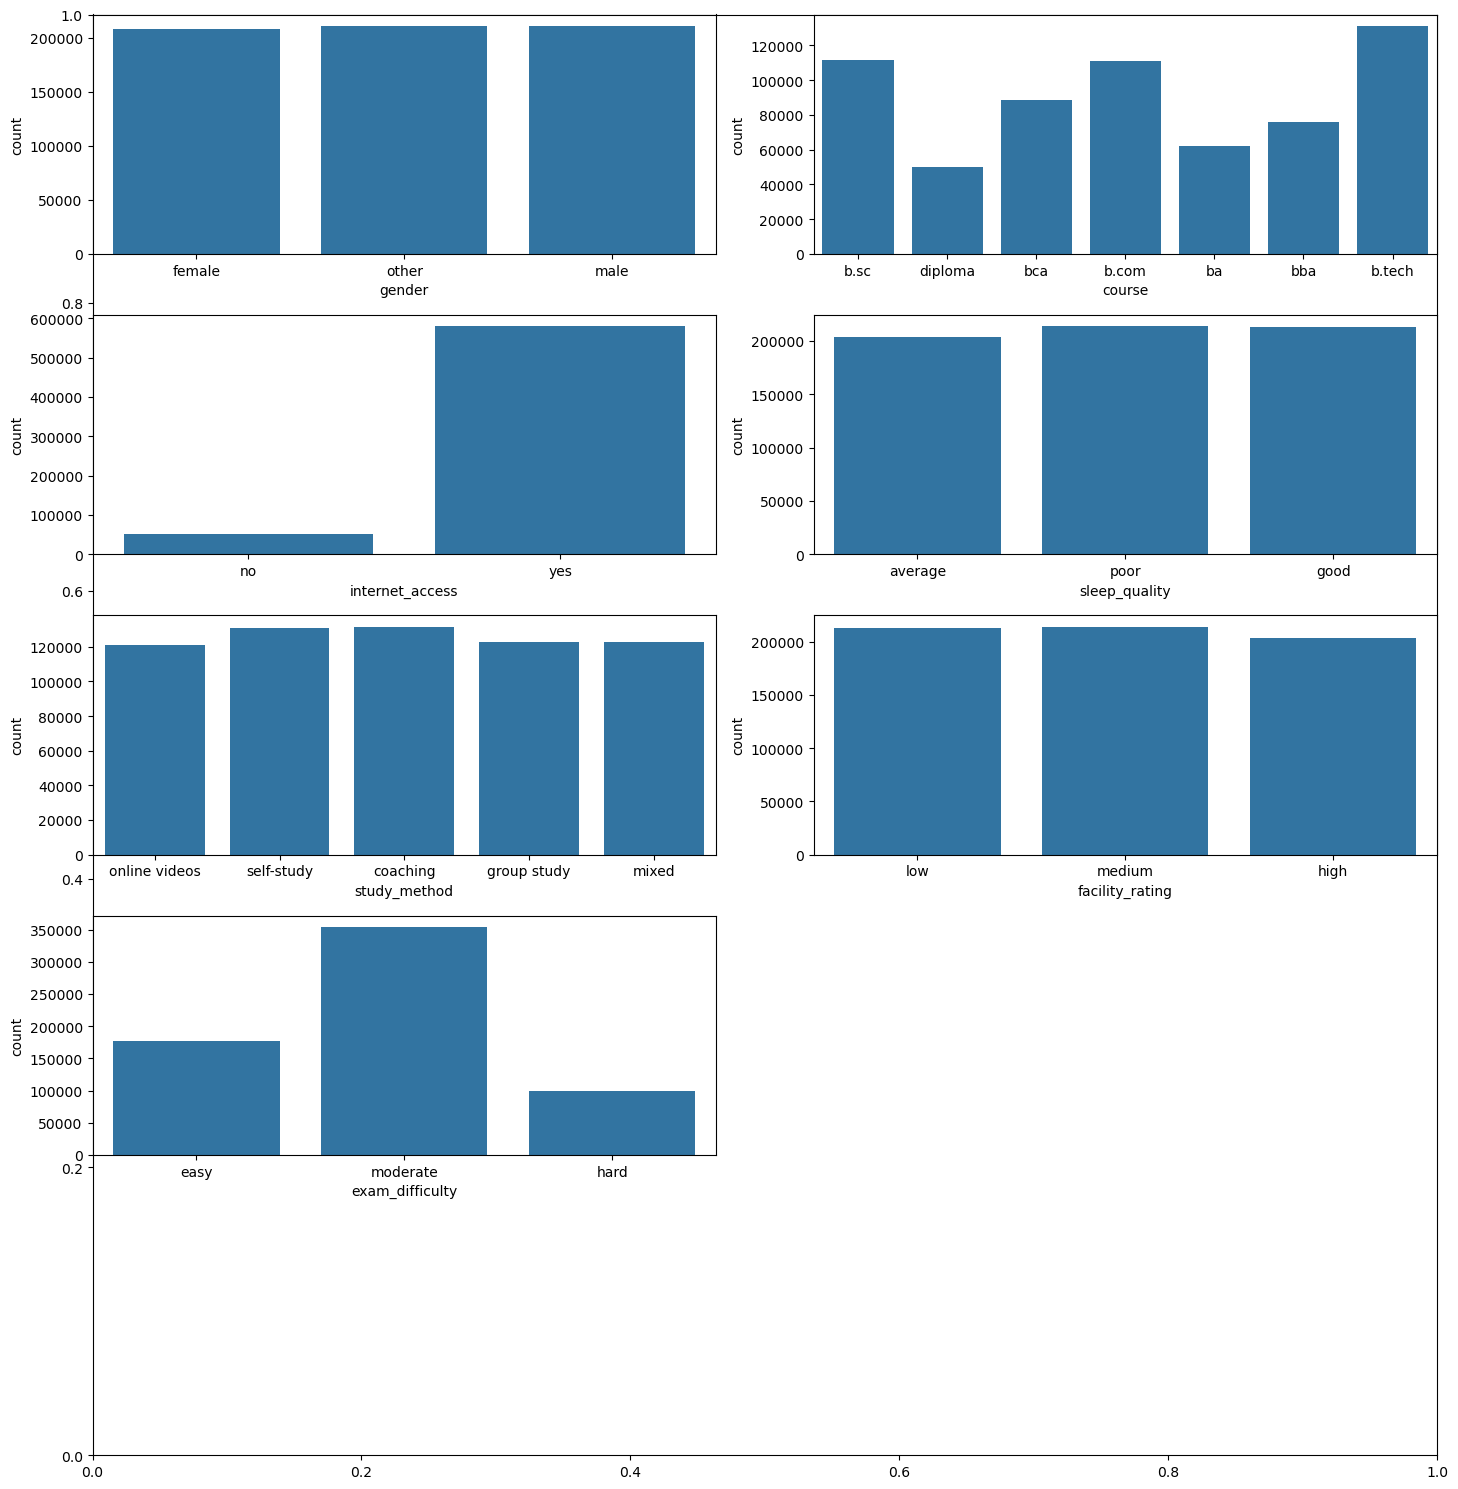

In [53]:
plt.subplots(figsize=(15, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(5, 2, i + 1)
    sb.countplot(data=MyData_train_df, x=col)
plt.tight_layout()
plt.show()

## Visualizing Numerical Distributions
* **histplot(): Plots distribution with optional KDE for density**


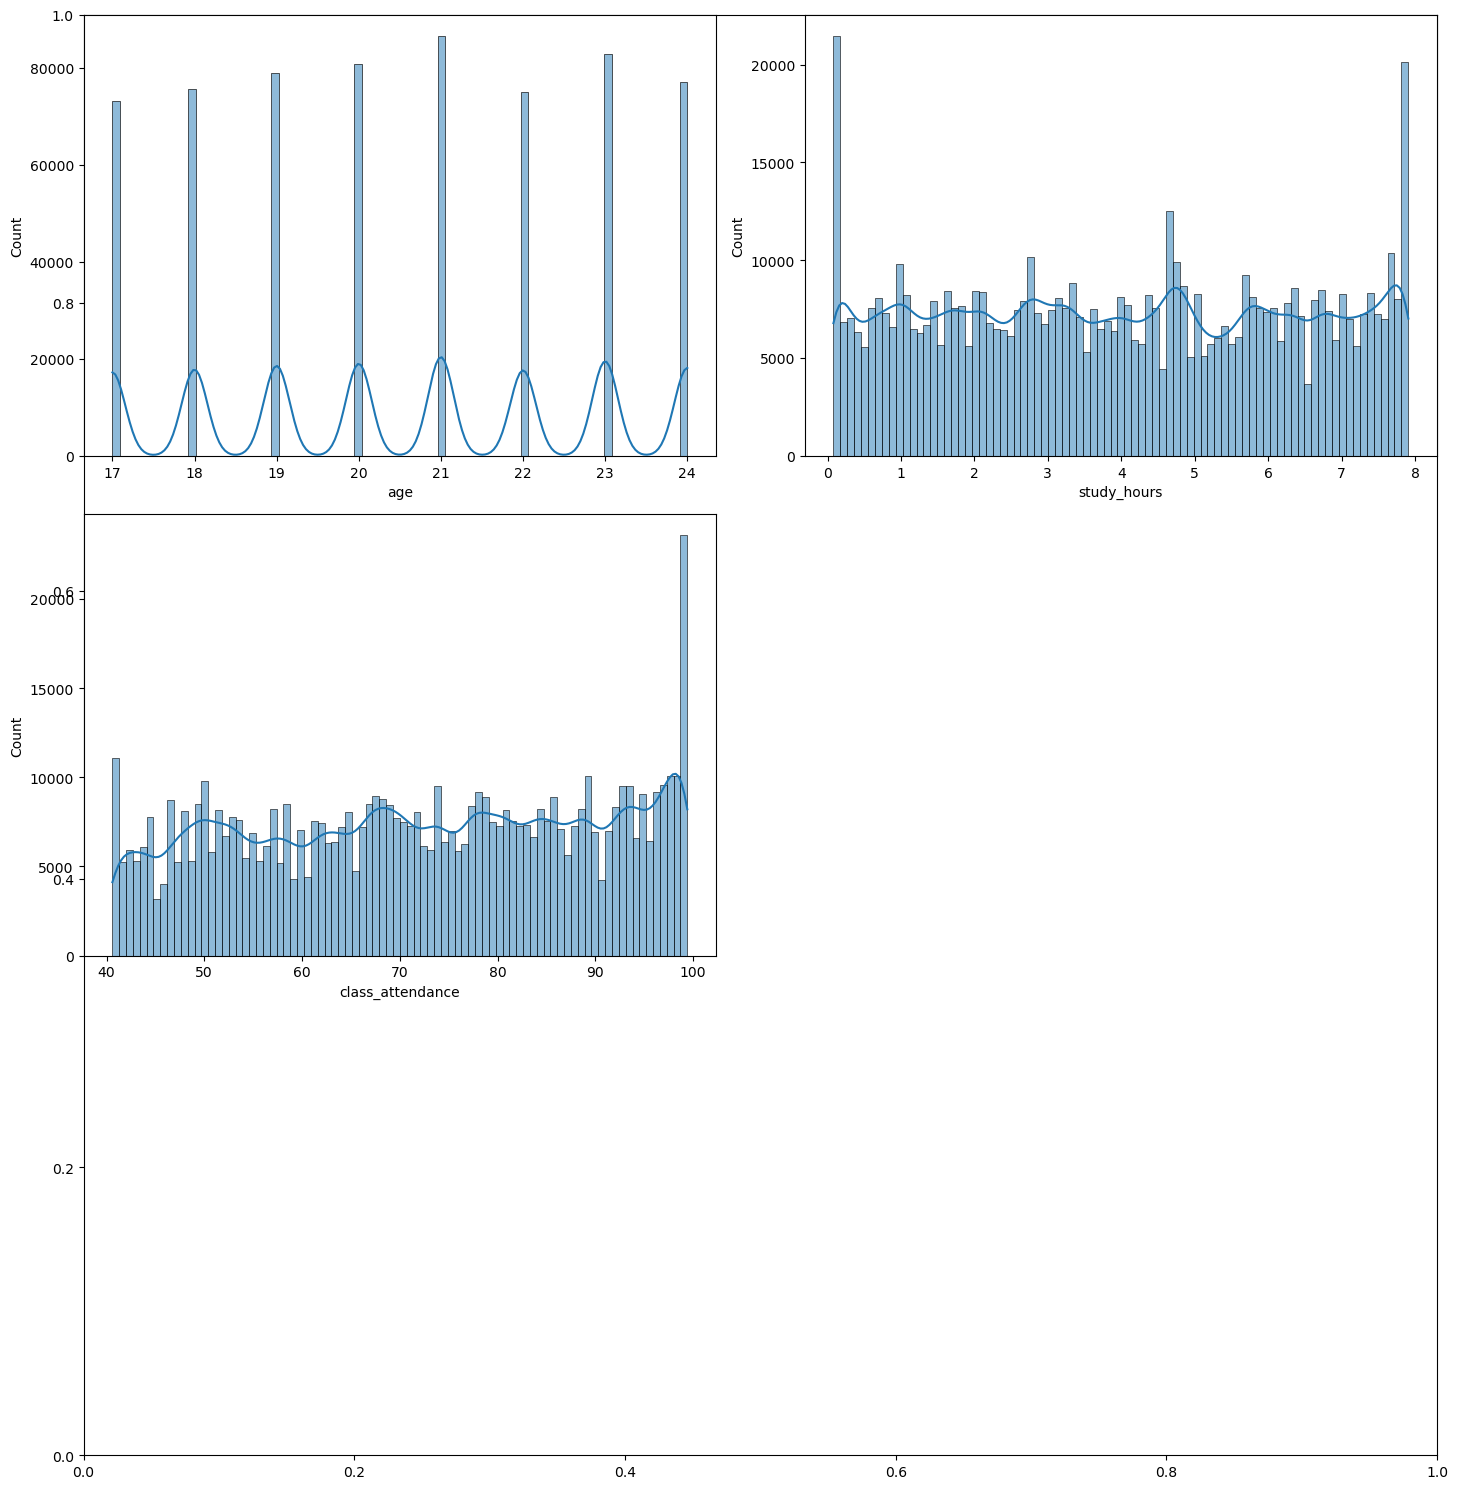

In [54]:
numeric_cols = ['age', 'study_hours', 'class_attendance']

plt.subplots(figsize=(15, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i + 1)
    sb.histplot(MyData_train_df[col], kde=True)
plt.tight_layout()
plt.show()

## Data Preprocessing
* **Log Transformation of Target Variable** 

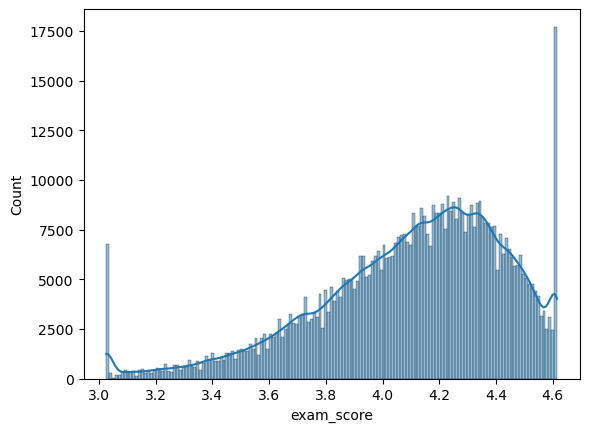

In [55]:
MyData_train_df['exam_score'] = np.log1p(MyData_train_df['exam_score'])
sb.histplot(MyData_train_df['exam_score'], kde=True)
plt.show()

## Binary Encoding of Categorical Features
* **map() – Converts categories to 0/1**
* **Ensures compatibility with LightGBM, XGBoost and other gradient boosting frameworks**

In [56]:
MyData_train_df['internet_access'] = MyData_train_df['internet_access'].map({'no': 0, 'yes': 1})
MyData_train_df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,0,4.9,average,online videos,low,easy,4.373238
1,1,18,other,diploma,4.95,94.8,1,4.7,poor,self-study,medium,moderate,3.864931
2,2,20,female,b.sc,4.68,92.6,1,5.8,poor,coaching,high,moderate,4.605170
3,3,19,male,b.sc,2.00,49.5,1,8.3,average,group study,high,moderate,4.172848
4,4,23,male,bca,7.65,86.9,1,9.6,good,self-study,high,easy,4.615121


## One-Hot Encoding Multi-class Features
* **pd.get_dummies() – Creates binary columns for each category**
* **Avoids ordinal bias that might be introduced with label encoding**

In [57]:
# List of all categorical variables to encode
categorical_vars = ['gender','course', 'exam_difficulty', 'facility_rating', 'study_method', 'sleep_quality']

# Create an empty DataFrame to store all dummy variables
dummies_df = pd.DataFrame(index=MyData_train_df.index)

# Track which variables were actually found and encoded
encoded_vars = []

# Generate dummies for each categorical variable and add to dummies_df
for var in categorical_vars:
    if var in MyData_train_df.columns:
        # Create dummy variables and add prefix to avoid column name conflicts
        dummy = pd.get_dummies(MyData_train_df[var], prefix=var).astype('int')
        dummies_df = pd.concat([dummies_df, dummy], axis=1)
        encoded_vars.append(var)
        print(f"Encoded {var} with {dummy.shape[1]} categories")
    else:
        print(f"Warning: '{var}' not found in the DataFrame")

# Concatenate the original DataFrame with all the dummy variables
MyData_train_df = pd.concat([MyData_train_df, dummies_df], axis=1)

# Drop the original categorical columns that were successfully encoded
if encoded_vars:
    MyData_train_df.drop(encoded_vars, axis=1, inplace=True)
    print(f"Dropped original categorical columns: {encoded_vars}")
else:
    print("No categorical columns were encoded or dropped")

Encoded gender with 3 categories
Encoded course with 7 categories
Encoded exam_difficulty with 3 categories
Encoded facility_rating with 3 categories
Encoded study_method with 5 categories
Encoded sleep_quality with 3 categories
Dropped original categorical columns: ['gender', 'course', 'exam_difficulty', 'facility_rating', 'study_method', 'sleep_quality']


## Correleation Matrix with the Log value of exam score

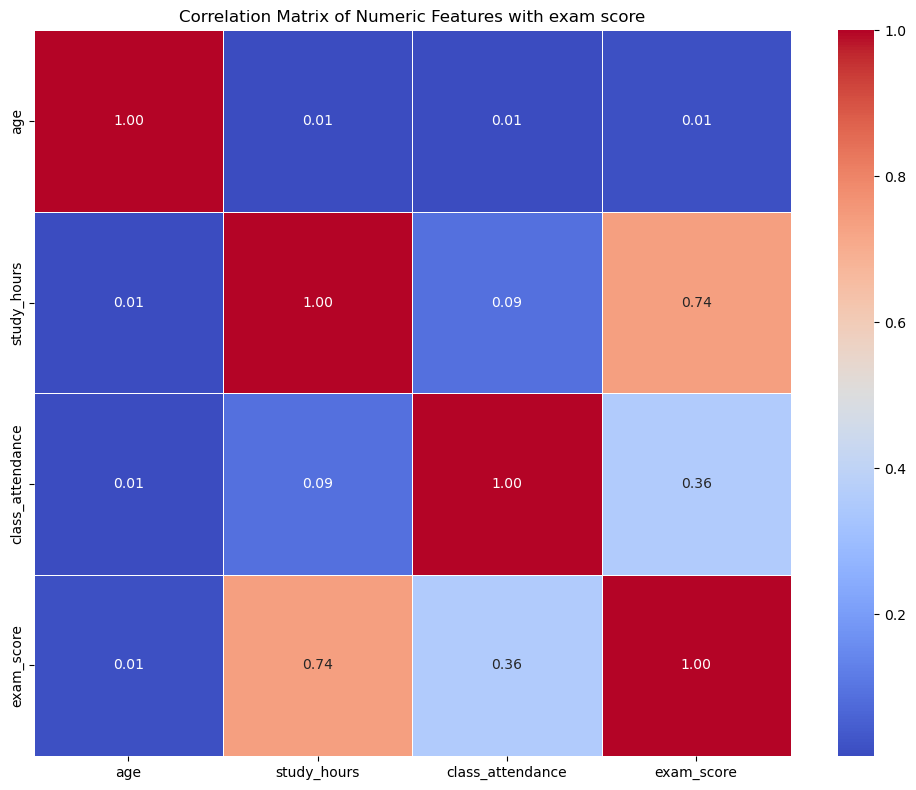


Correlations with exam_score:
exam_score          1.000000
study_hours         0.737525
class_attendance    0.358302
age                 0.014028
Name: exam_score, dtype: float64


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is in a DataFrame called 'df'
# If not, you'll need to load your data first

# Select only the numeric columns and the target variable
columns_to_analyze = ['age', 'study_hours', 'class_attendance', 'exam_score']
correlation_df = MyData_train_df[columns_to_analyze]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Create a heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features with exam score')
plt.tight_layout()
plt.show()

# If you want to specifically see correlations with the target variable only
target_correlations = correlation_matrix['exam_score'].sort_values(ascending=False)
print("\nCorrelations with exam_score:")
print(target_correlations)

In [59]:
target   = MyData_train_df['exam_score']
features = MyData_train_df.drop([col for col in ['id', 'exam_score'] if col in MyData_train_df.columns], axis=1)
#X_train = X_train.drop([col for col in ['id', 'exam_score'] if col in features.columns], axis=1)
#X_val   = X_val.drop([col for col in ['id', 'exam_score'] if col in features.columns], axis=1)
#X_train_fit_df = pd.DataFrame(X_train_fit, columns=X_train.columns)
#X_val_fit_df   = pd.DataFrame(X_val_fit, columns=X_val.columns)


In [60]:
target.head(5)

0    4.373238
1    3.864931
2    4.605170
3    4.172848
4    4.615121
Name: exam_score, dtype: float64

In [61]:
features.head(5)

,age,study_hours,class_attendance,internet_access,sleep_hours,gender_female,gender_male,gender_other,course_b.com,course_b.sc,...,facility_rating_low,facility_rating_medium,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,sleep_quality_average,sleep_quality_good,sleep_quality_poor
0,21,7.91,98.8,0,4.9,1,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
1,18,4.95,94.8,1,4.7,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,1
2,20,4.68,92.6,1,5.8,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,1
3,19,2.00,49.5,1,8.3,0,1,0,0,1,...,0,0,0,1,0,0,0,1,0,0
4,23,7.65,86.9,1,9.6,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [62]:
(
    models,
    scalers,
    mean_rmse,
    std_rmse,
    feature_importance,
    cv_results,
    oof_df
) = train_lightgbm_linear_with_stratified_cv(features,target,n_folds=10)

Training fold 1/10
Training fold 2/10
Training fold 3/10
Training fold 4/10
Training fold 5/10
Training fold 6/10
Training fold 7/10
Training fold 8/10
Training fold 9/10
Training fold 10/10

Stratified Cross-Validation Results
Mean RMSE: 0.1608 ± 0.0008


In [63]:
if len(oof_df) > 0:
    # Calculate RMSE for all folds
    rmse_oof = np.sqrt(
        mse(oof_df["actual"], oof_df["predicted"])
    )
    print(f"RMSE across all folds: {rmse_oof}")
    
    # Get unique fold values from the DataFrame
    unique_folds = oof_df["fold"].unique()
    
    # Calculate RMSE for each fold individually
    for fold_num in unique_folds:
        # Filter the DataFrame for the current fold
        oof_fold_df = oof_df[oof_df["fold"] == fold_num]
        
        # Calculate RMSE for this fold if there's data
        if len(oof_fold_df) > 0:
            rmse_fold = np.sqrt(
                mse(oof_fold_df["actual"], oof_fold_df["predicted"])
            )
            
            # Print the result
            print(f"RMSE for fold {fold_num}: {rmse_fold}")
        else:
            print(f"No data available for fold {fold_num}")
else:
    print("The DataFrame is empty. Please populate it with data before calculating metrics.")
    
    # Example of how to populate the DataFrame if needed:
    # fold = [0, 1, 2, 3, 4]  # Example fold values
    # y = [10, 20, 30, 40, 50]  # Example target values
    # oof_predictions = [12, 19, 32, 38, 53]  # Example predictions
    # 
    # oof_df = pd.DataFrame({
    #     "fold": fold,
    #     "actual": y,
    #     "predicted": oof_predictions
    # })

RMSE across all folds: 0.16081899908263503
RMSE for fold 10: 0.16117442863459383
RMSE for fold 4: 0.16134390978776772
RMSE for fold 3: 0.16162680900834098
RMSE for fold 1: 0.160524107791031
RMSE for fold 7: 0.15935343997129556
RMSE for fold 8: 0.15992982295035071
RMSE for fold 2: 0.16113625332512468
RMSE for fold 5: 0.16024045468082593
RMSE for fold 9: 0.1609751254986293
RMSE for fold 6: 0.16186810320411352


In [64]:
rmse_oof = np.sqrt(
    mse(oof_df["actual"], oof_df["predicted"])
)
print(rmse_oof)


0.16081899908263503


In [65]:
oof_df.head(5)


,fold,actual,predicted
0,10,4.373238,4.455525
1,4,3.864931,4.159475
2,3,4.605170,4.334068
3,10,4.172848,3.853668
4,1,4.615121,4.548463


In [66]:
oof_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   fold       630000 non-null  int64  
 1   actual     630000 non-null  float64
 2   predicted  630000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 14.4 MB


In [67]:
oof_df[oof_df["fold"] == 3].head()


,fold,actual,predicted
2,3,4.605170,4.334068
16,3,4.087656,4.267454
17,3,4.225373,4.181906
19,3,4.557030,4.426843
23,3,4.404277,4.280896


In [68]:
rmse_oof = np.sqrt(mse(oof_df["actual"], oof_df["predicted"]))
print(rmse_oof)

0.16081899908263503


In [69]:
fi_df = (
    pd.DataFrame(
        feature_importance.items(),
        columns=["feature", "importance"]
    )
    .sort_values("importance", ascending=False)
)

fi_df.head(100)   # top 20 features


,feature,importance
0,study_hours,2767.0
1,class_attendance,2568.3
2,sleep_hours,1558.4
3,age,574.3
4,sleep_quality_poor,320.4
5,study_method_coaching,304.9
6,facility_rating_high,259.6
7,facility_rating_low,249.0
8,sleep_quality_good,216.5
9,study_method_self-study,192.1


In [70]:
# Check if oof_df exists and has data
if 'oof_df' in locals() or 'oof_df' in globals():
    if len(oof_df) > 0:
        # Create a new DataFrame with the inverse log transformation
        comparison = pd.DataFrame({
            "fold": oof_df["fold"],  # Keep fold column as is
            "actual": np.expm1(oof_df["actual"]),  # Apply inverse log transformation
            "predicted": np.expm1(oof_df["predicted"])  # Apply inverse log transformation
        })
        
        print("Created oof_log_reversed_df with inverse log transformation")
        print(comparison.head())  # Display the first few rows
    else:
        print("The oof_df DataFrame is empty. Please populate it with data first.")
else:
    print("The oof_df DataFrame doesn't exist. Please create it first.")



Created oof_log_reversed_df with inverse log transformation
   fold  actual  predicted
0    10    78.3  85.101383
1     4    46.7  63.037889
2     3    99.0  75.253838
3    10    63.9  46.165736
4     1   100.0  93.487037


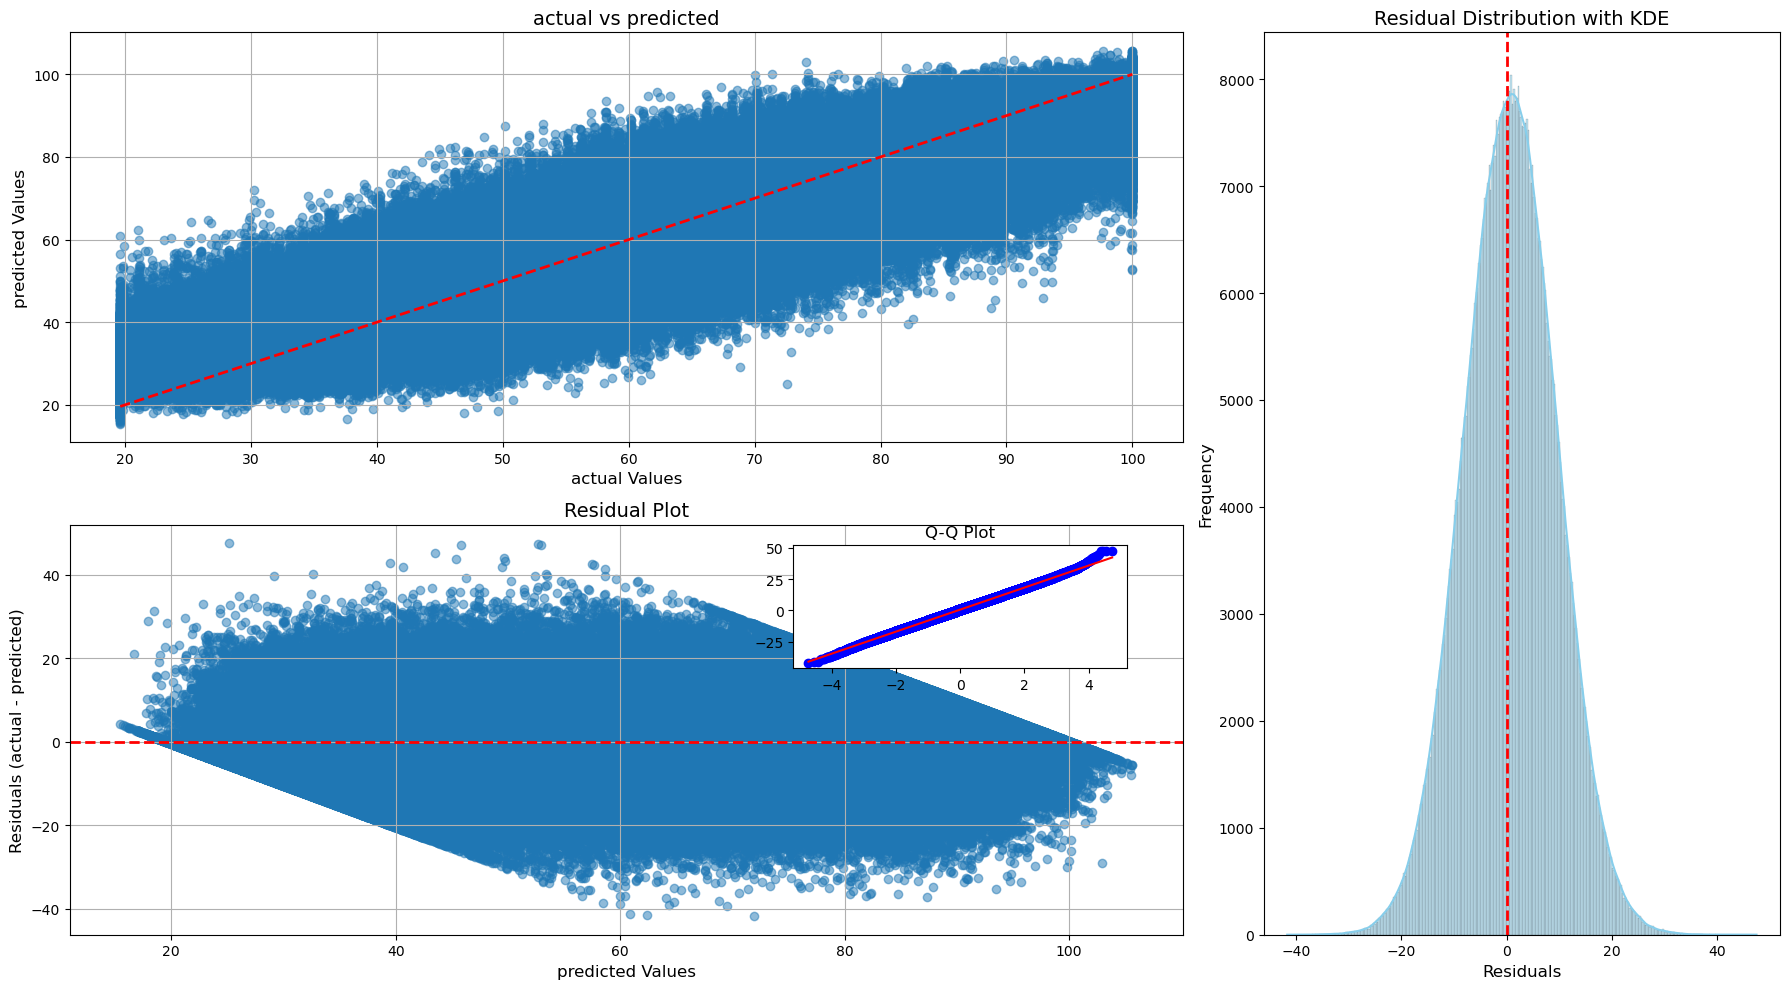

Residual Statistics:
Mean of Residuals: 0.6767
Standard Deviation of Residuals: 8.7712
Min Residual: -41.7026
Max Residual: 47.4545
Mean Absolute Error: 7.0168
Root Mean Squared Error: 8.7973


In [71]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Calculate residuals (actual - predicted)
comparison['Residuals'] = comparison['actual'] - comparison['predicted']

# Create a figure with three subplots
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3)

# Subplot 1: Scatter plot of Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.scatter(comparison['actual'], comparison['predicted'], alpha=0.5)
ax1.plot([comparison['actual'].min(), comparison['actual'].max()], 
         [comparison['actual'].min(), comparison['actual'].max()], 
         'r--', lw=2)  # Add a diagonal line for perfect predictions
ax1.set_xlabel('actual Values', fontsize=12)
ax1.set_ylabel('predicted Values', fontsize=12)
ax1.set_title('actual vs predicted', fontsize=14)
ax1.grid(True)

# Subplot 2: Residual plot
ax2 = fig.add_subplot(gs[1, 0:2])
ax2.scatter(comparison['predicted'], comparison['Residuals'], alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)  # Add a horizontal line at y=0
ax2.set_xlabel('predicted Values', fontsize=12)
ax2.set_ylabel('Residuals (actual - predicted)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14)
ax2.grid(True)

# Subplot 3: Histogram with KDE of residuals
ax3 = fig.add_subplot(gs[:, 2])
sns.histplot(comparison['Residuals'], kde=True, ax=ax3, color='skyblue')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_title('Residual Distribution with KDE', fontsize=14)
ax3.set_xlabel('Residuals', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)

# Add a Q-Q plot as an inset in the residual plot
from scipy import stats
inset_ax = ax2.inset_axes([0.65, 0.65, 0.3, 0.3])
stats.probplot(comparison['Residuals'], plot=inset_ax)
inset_ax.set_title('Q-Q Plot')
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Print some statistics about the residuals
print("Residual Statistics:")
print(f"Mean of Residuals: {comparison['Residuals'].mean():.4f}")
print(f"Standard Deviation of Residuals: {comparison['Residuals'].std():.4f}")
print(f"Min Residual: {comparison['Residuals'].min():.4f}")
print(f"Max Residual: {comparison['Residuals'].max():.4f}")
print(f"Mean Absolute Error: {np.abs(comparison['Residuals']).mean():.4f}")
print(f"Root Mean Squared Error: {np.sqrt((comparison['Residuals']**2).mean()):.4f}")

In [72]:
# Calculate percentage difference
comparison['Percent_Diff'] = abs(comparison['actual'] - comparison['predicted']) / comparison['actual'] * 100

# Count predictions in different variance ranges
count_under_10 = len(comparison[comparison['Percent_Diff'] <= 10])
count_10_to_50 = len(comparison[(comparison['Percent_Diff'] > 10) & (comparison['Percent_Diff'] <= 50)])
count_over_50 = len(comparison[comparison['Percent_Diff'] > 50])

# Display the comparison dataframe
# print(comparison)

# Display the counts
print("\nPrediction Variance Counts:")
print(f"Predictions varying ≤ 10%: {count_under_10}")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50}")
print(f"Predictions varying > 50%: {count_over_50}")

# Optional: Display as percentages of total
total = len(comparison)
print("\nAs percentages:")
print(f"Predictions varying ≤ 10%: {count_under_10/total*100:.1f}%")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50/total*100:.1f}%")
print(f"Predictions varying > 50%: {count_over_50/total*100:.1f}%")# Compare actual vs predicted

# Calculate percentage difference
comparison['Percent_Diff'] = abs(comparison['actual'] - comparison['predicted']) / comparison['actual'] * 100

# Count predictions in different variance ranges
count_under_10 = len(comparison[comparison['Percent_Diff'] <= 10])
count_10_to_50 = len(comparison[(comparison['Percent_Diff'] > 10) & (comparison['Percent_Diff'] <= 50)])
count_over_50 = len(comparison[comparison['Percent_Diff'] > 50])

# Display the comparison dataframe
# print(comparison)

# Display the counts
print("\nPrediction Variance Counts:")
print(f"Predictions varying ≤ 10%: {count_under_10}")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50}")
print(f"Predictions varying > 50%: {count_over_50}")

# Optional: Display as percentages of total
total = len(comparison)
print("\nAs percentages:")
print(f"Predictions varying ≤ 10%: {count_under_10/total*100:.1f}%")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50/total*100:.1f}%")
print(f"Predictions varying > 50%: {count_over_50/total*100:.1f}%")


Prediction Variance Counts:
Predictions varying ≤ 10%: 324772
Predictions varying > 10% and ≤ 50%: 293452
Predictions varying > 50%: 11776

As percentages:
Predictions varying ≤ 10%: 51.6%
Predictions varying > 10% and ≤ 50%: 46.6%
Predictions varying > 50%: 1.9%

Prediction Variance Counts:
Predictions varying ≤ 10%: 324772
Predictions varying > 10% and ≤ 50%: 293452
Predictions varying > 50%: 11776

As percentages:
Predictions varying ≤ 10%: 51.6%
Predictions varying > 10% and ≤ 50%: 46.6%
Predictions varying > 50%: 1.9%


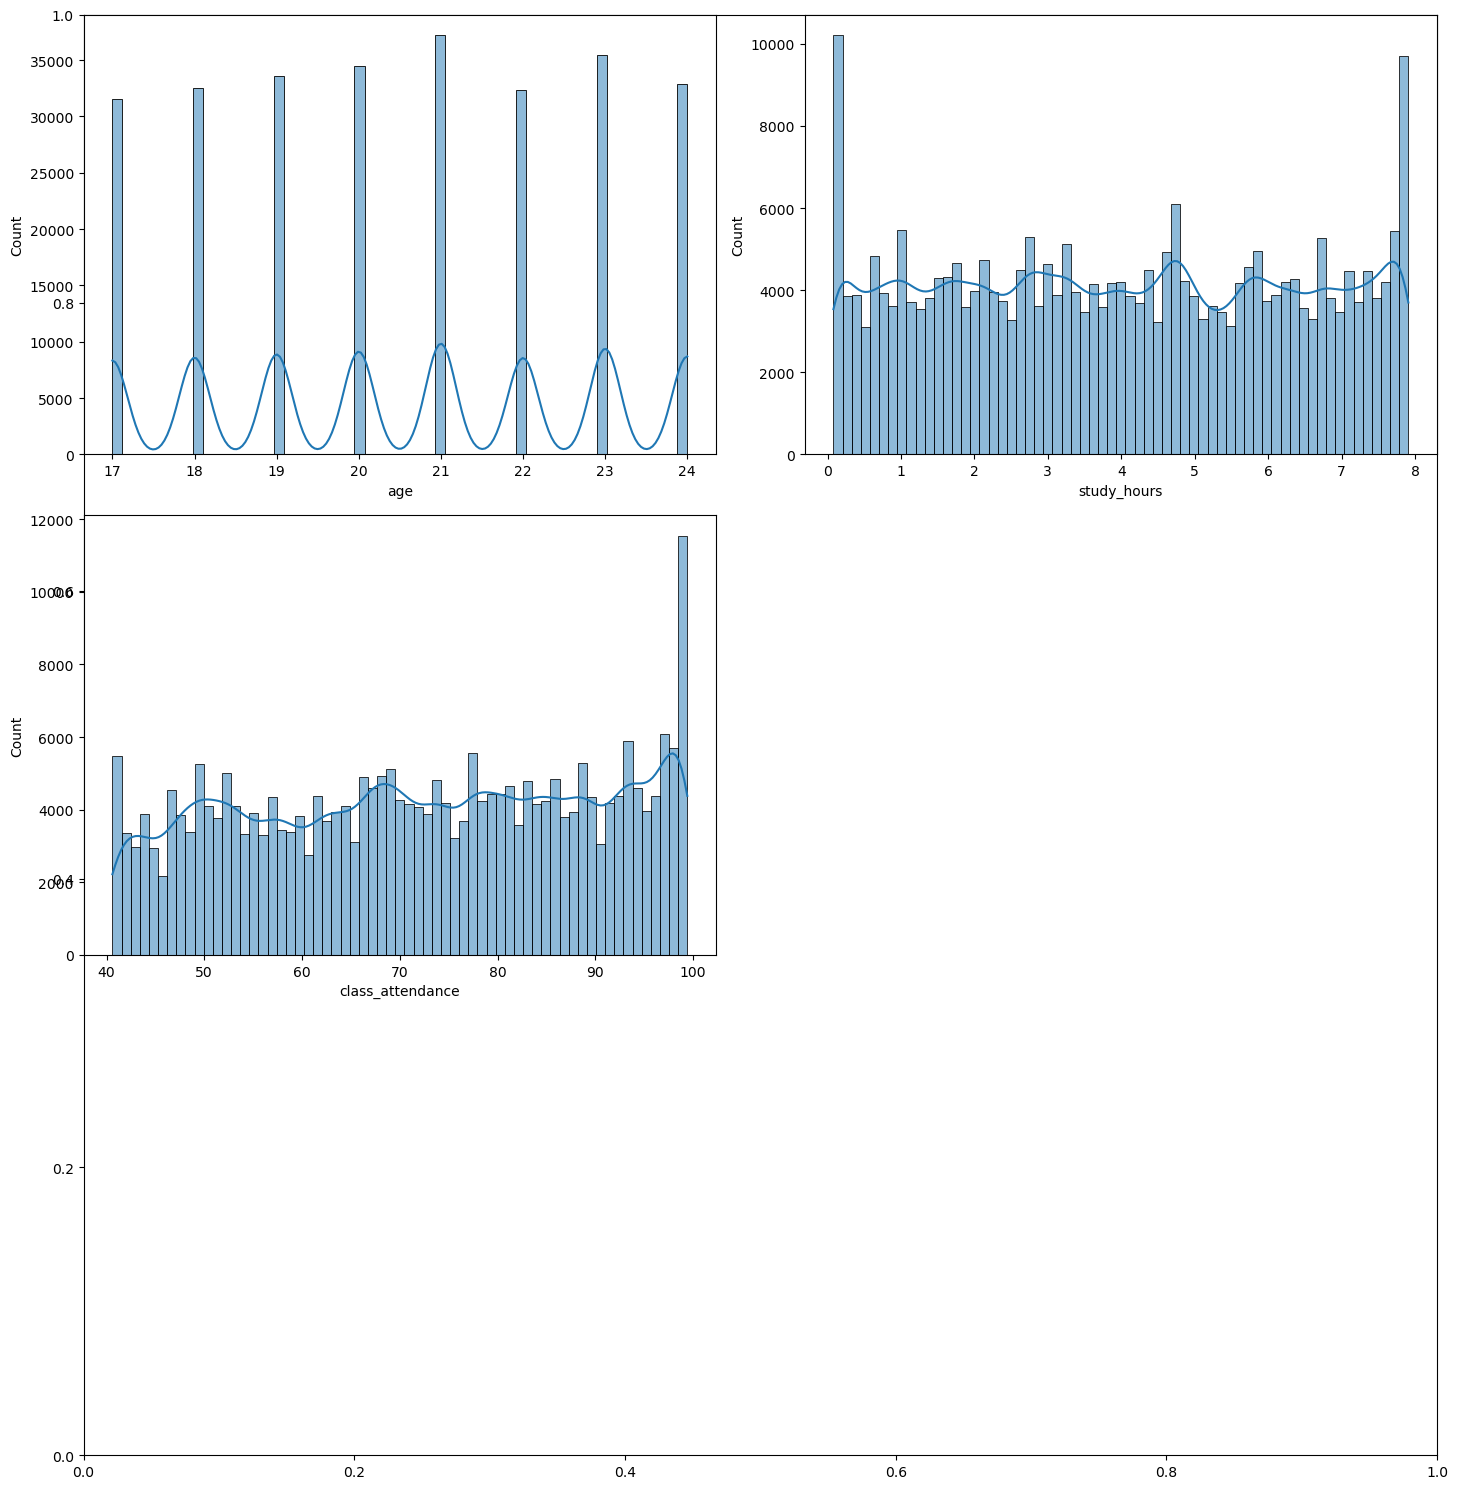

In [73]:
numeric_cols = ['age', 'study_hours', 'class_attendance']

plt.subplots(figsize=(15, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i + 1)
    sb.histplot(MyData_test_df[col], kde=True)
plt.tight_layout()
plt.show()

In [74]:
MyData_test_df['internet_access'] = MyData_test_df['internet_access'].map({'no': 0, 'yes': 1})
MyData_test_df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,1,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,0,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,1,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,1,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,1,9.2,average,coaching,low,moderate


In [75]:
# List of all categorical variables to encode
categorical_vars = ['gender','course', 'exam_difficulty', 'facility_rating', 'study_method', 'sleep_quality']

# Create an empty DataFrame to store all dummy variables
dummies_df = pd.DataFrame(index=MyData_test_df.index)

# Track which variables were actually found and encoded
encoded_vars = []

# Generate dummies for each categorical variable and add to dummies_df
for var in categorical_vars:
    if var in MyData_test_df.columns:
        # Create dummy variables and add prefix to avoid column name conflicts
        dummy = pd.get_dummies(MyData_test_df[var], prefix=var).astype('int')
        dummies_df = pd.concat([dummies_df, dummy], axis=1)
        encoded_vars.append(var)
        print(f"Encoded {var} with {dummy.shape[1]} categories")
    else:
        print(f"Warning: '{var}' not found in the DataFrame")

# Concatenate the original DataFrame with all the dummy variables
MyData_test_df = pd.concat([MyData_test_df, dummies_df], axis=1)

# Drop the original categorical columns that were successfully encoded
if encoded_vars:
    MyData_test_df.drop(encoded_vars, axis=1, inplace=True)
    print(f"Dropped original categorical columns: {encoded_vars}")
else:
    print("No categorical columns were encoded or dropped")

Encoded gender with 3 categories
Encoded course with 7 categories
Encoded exam_difficulty with 3 categories
Encoded facility_rating with 3 categories
Encoded study_method with 5 categories
Encoded sleep_quality with 3 categories
Dropped original categorical columns: ['gender', 'course', 'exam_difficulty', 'facility_rating', 'study_method', 'sleep_quality']


In [76]:
 MyData_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          270000 non-null  int64  
 1   age                         270000 non-null  int64  
 2   study_hours                 270000 non-null  float64
 3   class_attendance            270000 non-null  float64
 4   internet_access             270000 non-null  int64  
 5   sleep_hours                 270000 non-null  float64
 6   gender_female               270000 non-null  int64  
 7   gender_male                 270000 non-null  int64  
 8   gender_other                270000 non-null  int64  
 9   course_b.com                270000 non-null  int64  
 10  course_b.sc                 270000 non-null  int64  
 11  course_b.tech               270000 non-null  int64  
 12  course_ba                   270000 non-null  int64  
 13  course_bba    

In [77]:
 MyData_test_df.head(5)

,id,age,study_hours,class_attendance,internet_access,sleep_hours,gender_female,gender_male,gender_other,course_b.com,...,facility_rating_low,facility_rating_medium,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,sleep_quality_average,sleep_quality_good,sleep_quality_poor
0,630000,24,6.85,65.2,1,5.2,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
1,630001,18,6.61,45.0,0,9.3,0,1,0,0,...,1,0,1,0,0,0,0,0,0,1
2,630002,24,6.60,98.5,1,6.2,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
3,630003,24,3.03,66.3,1,5.7,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
4,630004,20,2.03,42.4,1,9.2,1,0,0,0,...,1,0,1,0,0,0,0,1,0,0


In [78]:
X_test_fit    = MyData_test_df.drop(columns=['id'])

In [79]:
X_test_fit.head(5)

,age,study_hours,class_attendance,internet_access,sleep_hours,gender_female,gender_male,gender_other,course_b.com,course_b.sc,...,facility_rating_low,facility_rating_medium,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,sleep_quality_average,sleep_quality_good,sleep_quality_poor
0,24,6.85,65.2,1,5.2,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
1,18,6.61,45.0,0,9.3,0,1,0,0,0,...,1,0,1,0,0,0,0,0,0,1
2,24,6.60,98.5,1,6.2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
3,24,3.03,66.3,1,5.7,0,1,0,0,0,...,0,1,0,0,1,0,0,1,0,0
4,20,2.03,42.4,1,9.2,1,0,0,0,0,...,1,0,1,0,0,0,0,1,0,0


In [80]:
import numpy as np
import pandas as pd

# Convert test data to numpy if needed
if isinstance(X_test_fit, pd.DataFrame):
    X_test_values = X_test_fit.values
else:
    X_test_values = X_test_fit

test_preds = []

for model, scaler in zip(models, scalers):
    X_test_scaled = scaler.transform(X_test_values)
    preds = model.predict(X_test_scaled)
    test_preds.append(preds)

# Average predictions across folds
test_predictions = np.mean(test_preds, axis=0)


In [81]:
test_pred_df = pd.DataFrame({
    "predicted": test_predictions
})

test_pred_df.head()


,predicted
0,4.283932
1,4.246144
2,4.488737
3,4.021516
4,3.876287


In [82]:
len(test_pred_df) == 270000

True

In [83]:
test_predictions_actual = np.expm1(test_predictions)
len(test_predictions_actual) == 270000


True

In [84]:
# 1. Check raw model predictions BEFORE expm1
print("Min prediction (log space):", test_predictions_actual.min())
print("Max prediction (log space):", test_predictions_actual.max())

# 2. Show a few negative predictions
negatives = test_predictions_actual[test_predictions_actual < 0]
print("Number of negative predictions:", len(negatives))
print("First 10 negative predictions:", negatives[:10])

# 3. Check for predictions > 100
gt100 = test_predictions_actual[test_predictions_actual > 100]
print("Number of Predictions > 100%:", len(gt100))
print("First 10 predictions > 100%:", gt100[:10])

Min prediction (log space): 15.85454753862275
Max prediction (log space): 105.47352135133448
Number of negative predictions: 0
First 10 negative predictions: []
Number of Predictions > 100%: 397
First 10 predictions > 100%: [100.0766034  100.32550699 101.63005184 101.60712795 103.18818789
 101.92548954 101.59453109 101.62783454 102.16250035 100.74399772]


In [85]:
test_predictions_actual =  np.clip(test_predictions_actual, 0, 100)

In [86]:
df_submission = pd.DataFrame({
    'id': MyData_test_df['id'],
    'exam_score': test_predictions_actual
})

print(df_submission.head(50))

        id  exam_score
0   630000   71.525025
1   630001   68.835628
2   630002   88.008959
3   630003   54.785585
4   630004   47.244737
5   630005   70.590625
6   630006   72.900643
7   630007   57.743597
8   630008   77.848735
9   630009   90.713540
10  630010   58.688462
11  630011   36.479917
12  630012   52.796182
13  630013   60.555411
14  630014   60.480774
15  630015   63.496637
16  630016   73.184171
17  630017   77.029789
18  630018   62.701137
19  630019   74.408278
20  630020   52.212041
21  630021   66.842652
22  630022   45.108434
23  630023   48.168833
24  630024   52.629744
25  630025   53.956329
26  630026   59.383489
27  630027   41.958356
28  630028   79.697570
29  630029   96.657595
30  630030   90.587008
31  630031   54.492836
32  630032   79.091567
33  630033   55.414954
34  630034   43.450666
35  630035   51.598728
36  630036   48.808860
37  630037   65.918884
38  630038   29.075712
39  630039   44.965006
40  630040   34.248859
41  630041   73.942952
42  630042 

In [87]:
df_submission.to_csv(r'..\..\results\submission_examscore.csv', index=False)
print("CSV file has been created successfully!")

CSV file has been created successfully!
